#### In this file A/B test is performed on different segments including: 
1. Age groups\
18–30, 31–45, 46–60, 60+
Does mobile outperform landline equally across all ages?
2. Job types
3. Previous campaign contact\
Users contacted before vs first-time contacts

In [3]:
import pandas as pd
import math
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')

from stats import z_test, check_srm, sample_size_calculator, segment_test

In [5]:
data = pd.read_csv("/Users/tolkyn.zhagipar/Desktop/pet-projects/fintech-ab-test/notebooks/cleaned_data.csv")
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,y_binary,is_returning
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0,0,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0,0,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0,0,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0,0,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0,0,0


In [11]:
#test cellular vs telephone conversion
cellular = data[data['contact'] == 'cellular']
telephone = data[data['contact'] == 'telephone']

In [13]:
# create age buckets
data['age_group'] = pd.cut(data['age'], 
                           bins=[18, 30, 45, 60, 100],
                           labels=['18-30', '31-45', '46-60', '60+'])

# run z_test per age group
age_results = []

for group in ['18-30', '31-45', '46-60', '60+']:
    seg = data[data['age_group'] == group]
    control = seg[seg['contact'] == 'telephone']
    treatment = seg[seg['contact'] == 'cellular']
    
    result = z_test(
        control['y'].sum(), len(control),
        treatment['y'].sum(), len(treatment)
    )
    result['age_group'] = group
    result['control_n'] = len(control)
    result['treatment_n'] = len(treatment)
    age_results.append(result)

age_df = pd.DataFrame(age_results)[['age_group', 'control_n', 'treatment_n',
                                     'control_rate', 'treatment_rate', 
                                     'lift', 'p_value']]
age_df['significant'] = age_df['p_value'] < 0.05
print(age_df)

  age_group  control_n  treatment_n  control_rate  treatment_rate    lift  \
0     18-30        297         4790        0.1414          0.2058  0.0644   
1     31-45        998        15640        0.0882          0.1262  0.0380   
2     46-60       1237         8046        0.0954          0.1295  0.0341   
3       60+        372          799        0.3817          0.4506  0.0688   

   p_value  significant  
0   0.0073         True  
1   0.0004         True  
2   0.0007         True  
3   0.0267         True  


In [17]:
job_results = []

for job in data['job'].unique():
    seg = data[data['job'] == job]
    control = seg[seg['contact'] == 'telephone']
    treatment = seg[seg['contact'] == 'cellular']
    
    # skip if group too small
    if len(control) < 30 or len(treatment) < 30:
        continue
    
    result = z_test(
        control['y'].sum(), len(control),
        treatment['y'].sum(), len(treatment)
    )
    result['job'] = job
    result['control_n'] = len(control)
    result['treatment_n'] = len(treatment)
    job_results.append(result)

job_df = pd.DataFrame(job_results)[['job', 'control_n', 'treatment_n',
                                     'control_rate', 'treatment_rate',
                                     'lift', 'p_value']]
job_df['significant'] = job_df['p_value'] < 0.05
job_df = job_df.sort_values('lift', ascending=False)
print(job_df)

              job  control_n  treatment_n  control_rate  treatment_rate  \
11        student         99          697        0.1919          0.3529   
4         unknown         46          131        0.1087          0.2061   
9      unemployed        100          891        0.1300          0.1942   
1      technician        321         5381        0.0841          0.1358   
7        services        228         2498        0.0702          0.1213   
3     blue-collar        611         5156        0.0622          0.0997   
0      management        471         7021        0.1274          0.1644   
10      housemaid        151          748        0.0927          0.1123   
8   self-employed         98         1084        0.1224          0.1411   
6          admin.        289         3354        0.1419          0.1577   
5         retired        405         1370        0.3185          0.2672   
2    entrepreneur         87          954        0.1839          0.0933   

      lift  p_value  sig

In [19]:
contact_results = []

for group, label in [(0, 'first_time'), (1, 'returning')]:
    seg = data[data['is_returning'] == group]
    control = seg[seg['contact'] == 'telephone']
    treat = seg[seg['contact'] == 'cellular']
    
    result = z_test(
        control['y'].sum(), len(control),
        treatment['y'].sum(), len(treatment)
    )
    result['contact_history'] = label
    result['control_n'] = len(control)
    result['treatment_n'] = len(treatment)
    contact_results.append(result)

contact_df = pd.DataFrame(contact_results)[['contact_history', 'control_n', 'treatment_n',
                                             'control_rate', 'treatment_rate',
                                             'lift', 'p_value']]
contact_df['significant'] = contact_df['p_value'] < 0.05
print(contact_df)

  contact_history  control_n  treatment_n  control_rate  treatment_rate  \
0      first_time       2275          697        0.1108          0.3529   
1       returning        631          697        0.2187          0.3529   

     lift  p_value  significant  
0  0.2422      0.0         True  
1  0.1342      0.0         True  


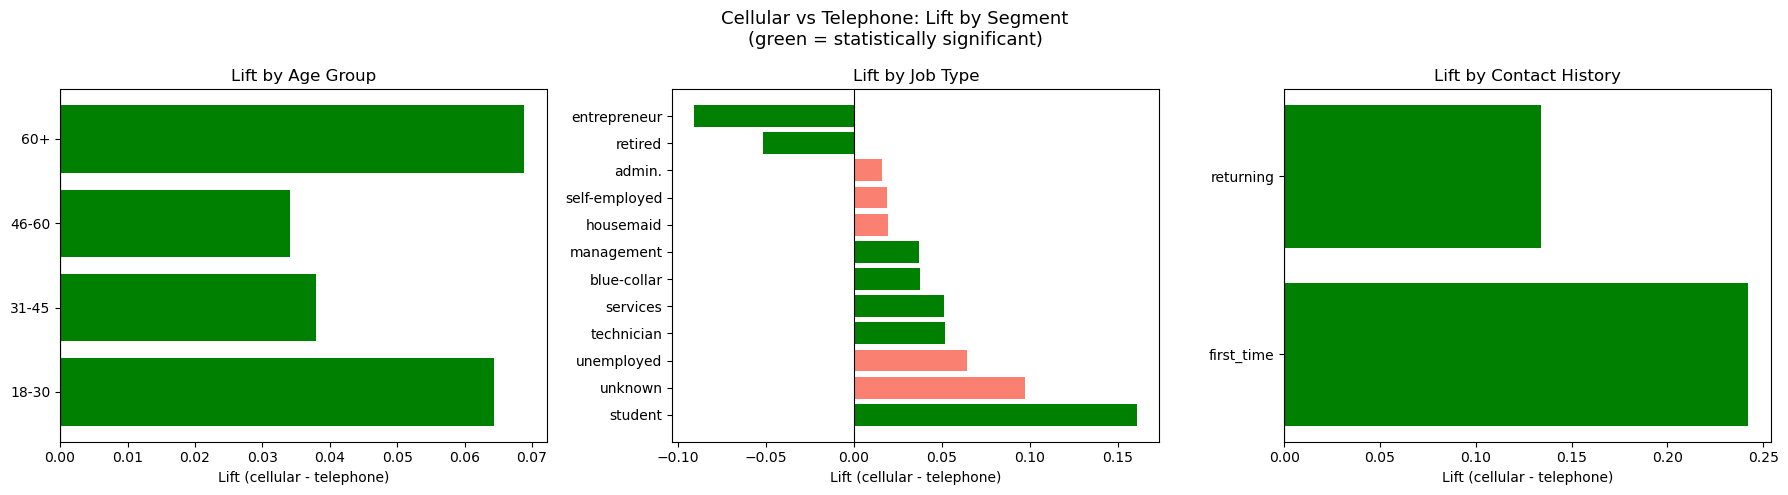

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# age groups
axes[0].barh(age_df['age_group'], age_df['lift'], 
             color=['green' if s else 'salmon' for s in age_df['significant']])
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Lift by Age Group')
axes[0].set_xlabel('Lift (cellular - telephone)')

# job type
axes[1].barh(job_df['job'], job_df['lift'],
             color=['green' if s else 'salmon' for s in job_df['significant']])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Lift by Job Type')
axes[1].set_xlabel('Lift (cellular - telephone)')

# contact history
axes[2].barh(contact_df['contact_history'], contact_df['lift'],
             color=['green' if s else 'salmon' for s in contact_df['significant']])
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Lift by Contact History')
axes[2].set_xlabel('Lift (cellular - telephone)')

plt.suptitle('Cellular vs Telephone: Lift by Segment\n(green = statistically significant)', 
             fontsize=13)
plt.tight_layout()
plt.show()

## Segmentation Findings

### Contact history
First-time contacts show a massive lift of +24.2pp (11% → 35.3%) when reached by cellular vs telephone. Returning contacts also benefit but less so (+13.4pp).

### Job Type
Cellular outperforms telephone for most segments, but two groups 
REVERSE the overall trend:

- Retired clients convert BETTER via telephone (30-day deposit subscription: 
  31.9% telephone vs 26.7% cellular, lift = -5.1pp, p=0.04)
- Entrepreneurs also prefer telephone (18.4% vs 9.3%, lift = -9.1pp, p=0.007)

This is the most actionable finding: a blanket cellular-first strategy 
would actively HARM conversion among retired and entrepreneur segments.


### Age groups 

Cellular outperforms telephone across all age groups (all p < 0.05).

Most notable: 60+ clients have the highest absolute conversion rates 
(38% telephone, 45% cellular) — this segment is highly valuable and 
responds well to either channel but especially cellular.

Combined with job segmentation finding (retired prefer telephone), 
this creates a nuance: older clients convert well via cellular overall, 
but retired specifically may still prefer telephone.


### Recommendation
Adopt a hybrid channel strategy:
- Default to cellular for most segments
- Route retired and entrepreneur contacts to telephone
- No channel preference needed for housemaid, self-employed, admin
- prioritize cellular for 18-30 and 60+ segments 
where lift is strongest (+6-7pp)